In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal
import matplotlib.patches as mpatches

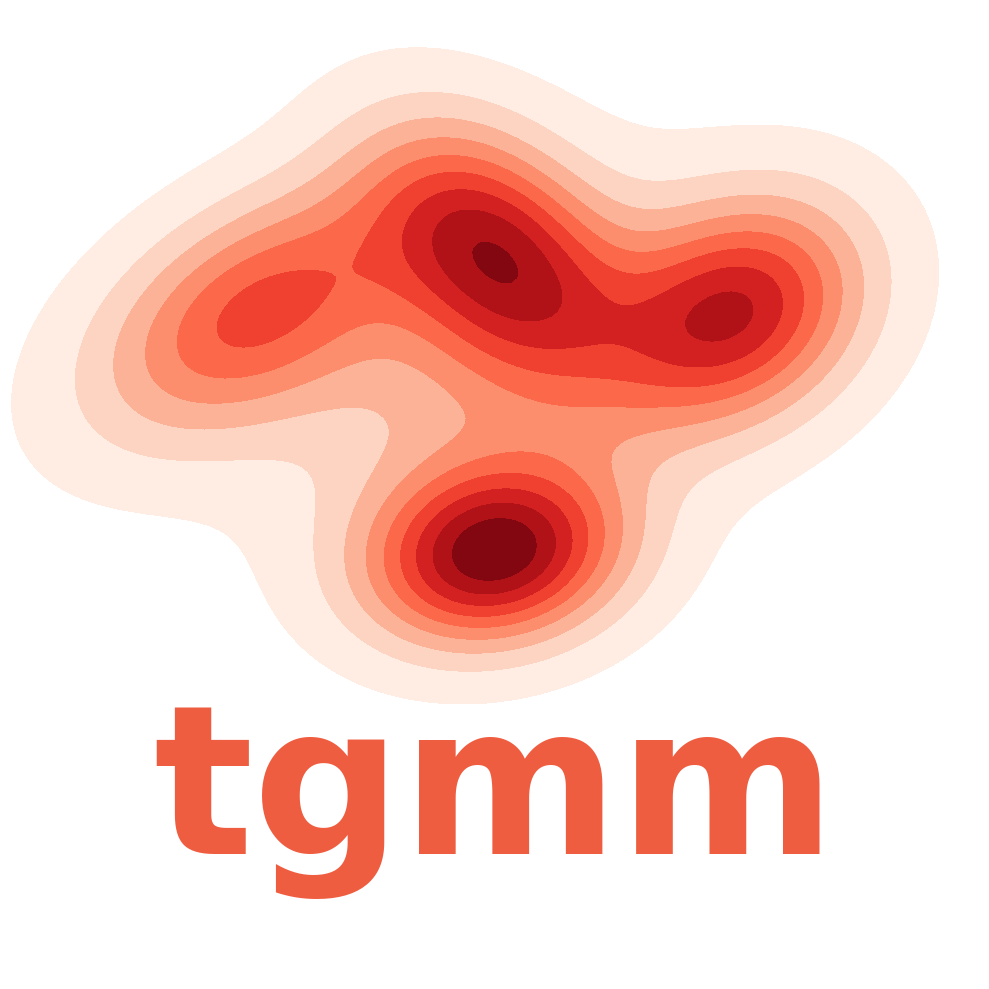

Logo saved to docs/assets/tgmm-logo.png


In [ ]:
# Create figure with transparent background - square format
fig, ax = plt.subplots(1, 1, figsize=(10, 10), facecolor='none')
ax.set_facecolor('none')

# Set up the coordinate system - square with tighter bounds
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.axis('off')

# Define Gaussian parameters
gaussians = [
    {'mean': [-2.0, 1.5], 'cov': [[0.8, 0.3], [0.3, 0.5]], 'color': "#EE4C2C", 'alpha': 0.5},
    {'mean': [0.0, 2.0], 'cov': [[0.5, -0.2], [-0.2, 0.5]], 'color': "#EE4C2C", 'alpha': 0.5},
    {'mean': [2.0, 1.5], 'cov': [[0.5, 0.1], [0.1, 0.4]], 'color': "#EE4C2C", 'alpha': 0.5},
    {'mean': [0.0, -0.5], 'cov': [[0.5, 0.05], [0.05, 0.25]], 'color': "#EE4C2C", 'alpha': 0.5},
    {'mean': [0.0, 1.0], 'cov': [[1.5, 0.3], [0.3, 1.0]], 'color': "#EE4C2C", 'alpha': 0.5},
]

# Create a grid for plotting
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# Combine all Gaussians into a single density map
Z_combined = np.zeros_like(X)
for gauss in gaussians:
    rv = multivariate_normal(gauss['mean'], gauss['cov'])
    Z_combined += rv.pdf(pos)

# Plot the combined filled contours with threshold to remove background
# Only show areas with density above a certain threshold
threshold = Z_combined.max() * 0.05  # Show only densities above 5% of max
levels = np.linspace(threshold, Z_combined.max(), 10)
ax.contourf(X, Y, Z_combined, levels=levels, cmap='Reds', alpha=1.0)

# Add text "tgmm" - PyTorch orange color
ax.text(0, -2.5, 'tgmm', 
        fontsize=150, 
        fontweight='bold',
        ha='center', 
        va='center',
        color='#EE4C2C',
        family='sans-serif',
        alpha=0.9)

plt.tight_layout()

# Save with transparent background - no padding
plt.savefig('tgmm-logo.png', 
            dpi=300, 
            bbox_inches='tight', 
            transparent=True,
            pad_inches=0)

plt.show()